# Notebook 1: MIMU 特征提取

在每个滑动窗口中提取 MIMU 特征，为每个窗口标记运动类型。

**可行性检查**: t-SNE 散点图验证不同运动类型在特征空间中的可分性。

**输出产物**: `artifacts/mimu_features_all.pkl`

In [ ]:
import pickle
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import welch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path(r"D:\data\PPG_HeartRate\Algorithm\outline-PPGtoHR")
DATA_DIR = PROJECT_ROOT / "docs" / "research" / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "docs" / "research" / "artifacts"
sys.path.insert(0, str(PROJECT_ROOT / "python" / "src"))

# seaborn style 必须先于字体设置, 否则会覆盖 rcParams
sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 配置与数据发现

数据目录为扁平结构: 所有 CSV 文件位于 `data/`，不按运动分子目录组织。
通过文件名前缀识别运动类别。

In [4]:
EXERCISES = {
    "jump_rope": {"prefix": "tiaosheng", "label": "跳绳", "complexity": "simple"},
    "arm_curl": {"prefix": "wanju", "label": "手臂弯举", "complexity": "simple"},
    "push_up": {"prefix": "fuwo", "label": "俯卧撑", "complexity": "simple"},
    "jumping_jack": {"prefix": "kaihe", "label": "开合跳", "complexity": "simple"},
    "burpee": {"prefix": "bobi", "label": "波比跳", "complexity": "complex"},
}
PREFIX_MAP = {info["prefix"]: name for name, info in EXERCISES.items()}

FS = 100
WIN_SEC = 8
STEP_SEC = 1
WIN_SAMPLES = WIN_SEC * FS

# 运动段判定阈值: 窗口内 ACC 幅值标准差超过此值判定为运动段
MOTION_THRESHOLD = 0.05  # g

# CSV 列名映射: raw CSV header -> 内部短名
MIMU_COLUMN_MAP = {
    "AccX(g)": "AccX", "AccY(g)": "AccY", "AccZ(g)": "AccZ",
    "GyroX(dps)": "GyroX", "GyroY(dps)": "GyroY", "GyroZ(dps)": "GyroZ",
}
MIMU_CHANNELS = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]


def discover_csv_files(data_dir: Path) -> list[tuple[Path, str, str]]:
    """发现所有非 ref 的 CSV 文件, 返回 [(path, exercise_name, stem)]."""
    files = []
    for csv_file in sorted(data_dir.glob("multi_*.csv")):
        if csv_file.stem.endswith("_ref"):
            continue
        m = re.match(r"multi_([a-z]+)", csv_file.stem)
        if not m:
            continue
        prefix = m.group(1)
        exercise = PREFIX_MAP.get(prefix)
        if exercise is None:
            continue
        files.append((csv_file, exercise, csv_file.stem))
    return files


all_files = discover_csv_files(DATA_DIR)
print("数据文件:")
for csv_f, name, stem in all_files:
    label = EXERCISES[name]["label"]
    tag = "[复杂]" if EXERCISES[name]["complexity"] == "complex" else "[简单]"
    print(f"  {tag} {label}: {csv_f.name}")

数据文件:
  [复杂] 波比跳: multi_bobi1.csv
  [复杂] 波比跳: multi_bobi2.csv
  [简单] 俯卧撑: multi_fuwo1.csv
  [简单] 俯卧撑: multi_fuwo2.csv
  [简单] 开合跳: multi_kaihe1.csv
  [简单] 开合跳: multi_kaihe2.csv
  [简单] 跳绳: multi_tiaosheng2.csv
  [简单] 跳绳: multi_tiaosheng3.csv
  [简单] 手臂弯举: multi_wanju1.csv
  [简单] 手臂弯举: multi_wanju2.csv


## 2. 特征提取函数

对每个滑动窗口提取 75 维 MIMU 特征:
- 6 通道 (AccX/Y/Z, GyroX/Y/Z) 各 10 维 (7 时域 + 3 频域) = 60 维
- 加速度/陀螺仪幅度各 4 维 = 8 维
- 跨通道相关系数 7 维
- 总计 75 维

In [5]:
TIME_FEATURES = ["mean", "std", "min", "max", "range", "energy", "zcr"]
FREQ_FEATURES = ["dominant_freq", "spectral_entropy", "spectral_flatness"]
MAG_FEATURES = ["mean", "std", "energy", "dominant_freq"]


def extract_time_domain_features(signal: np.ndarray) -> dict:
    return {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "min": np.min(signal),
        "max": np.max(signal),
        "range": np.max(signal) - np.min(signal),
        "energy": np.mean(signal ** 2),
        "zcr": np.sum(np.diff(np.sign(signal)) != 0) / (len(signal) - 1),
    }


def extract_freq_domain_features(signal: np.ndarray, fs: int = 100) -> dict:
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 256))
    psd_sum = np.sum(psd)
    if psd_sum == 0:
        return {"dominant_freq": 0.0, "spectral_entropy": 0.0, "spectral_flatness": 0.0}
    non_dc = psd[1:]
    dominant_freq = freqs[1:][np.argmax(non_dc)] if len(non_dc) > 0 and np.max(non_dc) > 0 else 0.0
    psd_norm = psd / psd_sum
    psd_norm = psd_norm[psd_norm > 0]
    spectral_entropy = -np.sum(psd_norm * np.log(psd_norm))
    psd_pos = psd[psd > 0]
    spectral_flatness = (np.exp(np.mean(np.log(psd_pos))) / np.mean(psd_pos)) if len(psd_pos) > 0 else 0.0
    return {"dominant_freq": dominant_freq, "spectral_entropy": spectral_entropy, "spectral_flatness": spectral_flatness}


def build_feature_names() -> list[str]:
    names = []
    for ch in MIMU_CHANNELS:
        names.extend(f"{ch}_{f}" for f in TIME_FEATURES)
        names.extend(f"{ch}_{f}" for f in FREQ_FEATURES)
    for mag_name in ["acc_mag", "gyro_mag"]:
        names.extend(f"{mag_name}_{f}" for f in MAG_FEATURES)
    names.extend(["corr_acc_gyro"])
    names.extend(["corr_AccX_AccY", "corr_AccX_AccZ", "corr_AccY_AccZ"])
    names.extend(["corr_GyroX_GyroY", "corr_GyroX_GyroZ", "corr_GyroY_GyroZ"])
    return names


FEATURE_NAMES = build_feature_names()
print(f"特征维度: {len(FEATURE_NAMES)}")


def extract_window_features(accx, accy, accz, gyrox, gyroy, gyroz, fs=100) -> np.ndarray:
    features = []
    for sig in [accx, accy, accz, gyrox, gyroy, gyroz]:
        td = extract_time_domain_features(sig)
        fd = extract_freq_domain_features(sig, fs)
        features.extend(td[f] for f in TIME_FEATURES)
        features.extend(fd[f] for f in FREQ_FEATURES)

    acc_mag = np.sqrt(accx**2 + accy**2 + accz**2)
    gyro_mag = np.sqrt(gyrox**2 + gyroy**2 + gyroz**2)

    for mag in [acc_mag, gyro_mag]:
        td = extract_time_domain_features(mag)
        fd = extract_freq_domain_features(mag, fs)
        features.extend([td["mean"], td["std"], td["energy"], fd["dominant_freq"]])

    def safe_corr(a, b):
        return np.corrcoef(a, b)[0, 1] if np.std(a) != 0 and np.std(b) != 0 else 0.0

    features.append(safe_corr(acc_mag, gyro_mag))
    features.append(safe_corr(accx, accy))
    features.append(safe_corr(accx, accz))
    features.append(safe_corr(accy, accz))
    features.append(safe_corr(gyrox, gyroy))
    features.append(safe_corr(gyrox, gyroz))
    features.append(safe_corr(gyroy, gyroz))

    return np.array(features, dtype=float)

特征维度: 75


## 3. 批量提取

In [6]:
def extract_features_for_file(csv_path: Path) -> pd.DataFrame:
    """直接读取 CSV 提取 MIMU 特征, 并标记运动/静息段."""
    raw = pd.read_csv(csv_path, encoding="utf-8-sig")
    rename_map = {k: v for k, v in MIMU_COLUMN_MAP.items() if k in raw.columns}
    df = raw.rename(columns=rename_map)
    if "Time_s" not in df.columns:
        if "Time(s)" in raw.columns:
            df["Time_s"] = raw["Time(s)"]
        else:
            df["Time_s"] = np.arange(len(df), dtype=float) / float(FS)

    n_samples = len(df)
    start_idx = int(1.0 * FS)
    buffer_samples = int(10.0 * FS)
    end_idx = n_samples - buffer_samples

    records = []
    for win_start in range(start_idx, end_idx - WIN_SAMPLES + 1, STEP_SEC * FS):
        win_end = win_start + WIN_SAMPLES
        window_time = df["Time_s"].iloc[win_start]
        accx = df["AccX"].iloc[win_start:win_end].to_numpy()
        accy = df["AccY"].iloc[win_start:win_end].to_numpy()
        accz = df["AccZ"].iloc[win_start:win_end].to_numpy()
        gyrox = df["GyroX"].iloc[win_start:win_end].to_numpy()
        gyroy = df["GyroY"].iloc[win_start:win_end].to_numpy()
        gyroz = df["GyroZ"].iloc[win_start:win_end].to_numpy()
        # 运动段判定: ACC 幅值标准差
        acc_mag = np.sqrt(accx**2 + accy**2 + accz**2)
        is_motion = np.std(acc_mag) > MOTION_THRESHOLD
        feat_vec = extract_window_features(accx, accy, accz, gyrox, gyroy, gyroz, FS)
        records.append({"window_time": window_time, "features": feat_vec, "is_motion": is_motion})
    return pd.DataFrame(records)


print("开始批量提取特征...")
all_records = []
for csv_f, name, stem in all_files:
    info = EXERCISES[name]
    print(f"  处理: {csv_f.name} ...", end=" ")
    try:
        df_feats = extract_features_for_file(csv_f)
        df_feats["exercise"] = name
        df_feats["exercise_label"] = info["label"]
        df_feats["complexity"] = info["complexity"]
        df_feats["file_name"] = stem
        all_records.append(df_feats)
        n_motion = df_feats["is_motion"].sum()
        print(f"{len(df_feats)} 窗口 (运动 {n_motion}, 静息 {len(df_feats) - n_motion})")
    except Exception as e:
        print(f"错误: {e}")

df_all = pd.concat(all_records, ignore_index=True)
print(f"\n总计: {len(df_all)} 个窗口, 来自 {df_all['file_name'].nunique()} 个文件")
n_m = df_all["is_motion"].sum()
print(f"运动段: {n_m} ({n_m/len(df_all)*100:.1f}%), 静息段: {len(df_all)-n_m} ({(len(df_all)-n_m)/len(df_all)*100:.1f}%)")
print("\n各运动类型窗口统计 (运动/静息):")
print(df_all.groupby(["complexity", "exercise_label", "is_motion"]).size().unstack(fill_value=0).to_string())

开始批量提取特征...
  处理: multi_bobi1.csv ... 217 窗口 (运动 60, 静息 157)
  处理: multi_bobi2.csv ... 218 窗口 (运动 60, 静息 158)
  处理: multi_fuwo1.csv ... 189 窗口 (运动 26, 静息 163)
  处理: multi_fuwo2.csv ... 188 窗口 (运动 23, 静息 165)
  处理: multi_kaihe1.csv ... 217 窗口 (运动 68, 静息 149)
  处理: multi_kaihe2.csv ... 214 窗口 (运动 64, 静息 150)
  处理: multi_tiaosheng2.csv ... 217 窗口 (运动 63, 静息 154)
  处理: multi_tiaosheng3.csv ... 213 窗口 (运动 57, 静息 156)
  处理: multi_wanju1.csv ... 189 窗口 (运动 66, 静息 123)
  处理: multi_wanju2.csv ... 189 窗口 (运动 65, 静息 124)

总计: 2051 个窗口, 来自 10 个文件
运动段: 552 (26.9%), 静息段: 1499 (73.1%)

各运动类型窗口统计 (运动/静息):
is_motion                  False  True 
complexity exercise_label              
complex    波比跳               315    120
simple     俯卧撑               328     49
           开合跳               299    132
           手臂弯举              247    131
           跳绳                310    120


## 4. 特征矩阵与 NaN 修复

In [7]:
X = np.stack(df_all["features"].values)
y = df_all["exercise"].values
labels = df_all["exercise_label"].values

nan_mask = ~np.isfinite(X)
if nan_mask.any():
    col_medians = np.nanmedian(X, axis=0)
    for j in range(X.shape[1]):
        mask = nan_mask[:, j]
        X[mask, j] = col_medians[j] if np.isfinite(col_medians[j]) else 0.0
    print(f"已修复 {nan_mask.sum()} 个 NaN/Inf 值")

print(f"特征矩阵: {X.shape}")
print(f"标签分布: {dict(zip(*np.unique(y, return_counts=True)))}")

特征矩阵: (2051, 75)
标签分布: {'arm_curl': np.int64(378), 'burpee': np.int64(435), 'jump_rope': np.int64(430), 'jumping_jack': np.int64(431), 'push_up': np.int64(377)}


## 5. 可行性检查: PCA & t-SNE

PCA 解释方差比: [0.57821021 0.08658331]
累计: 66.48%


C:\Users\26541\AppData\Local\Temp\ipykernel_13060\750045647.py:18: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\750045647.py:18: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\750045647.py:18: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\750045647.py:18: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\750045647.py:18: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\750045647.py:18: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missi

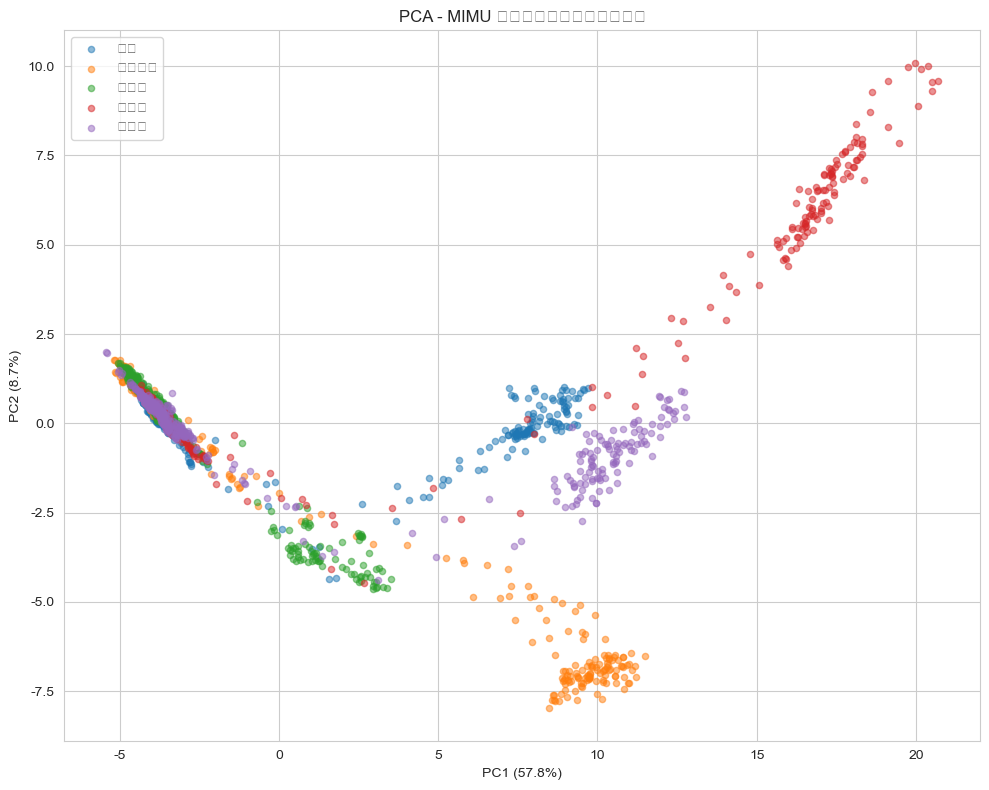

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA 解释方差比: {pca.explained_variance_ratio_}")
print(f"累计: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(10, 8))
for name in EXERCISES:
    mask = y == name
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=EXERCISES[name]["label"],
               alpha=0.5, s=20)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA - MIMU 特征空间中的运动类型分布")
ax.legend()
plt.tight_layout()
plt.show()

d:\Anaconda\envs\ppg-hr\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3882444945.py:13: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3882444945.py:13: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3882444945.py:13: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7

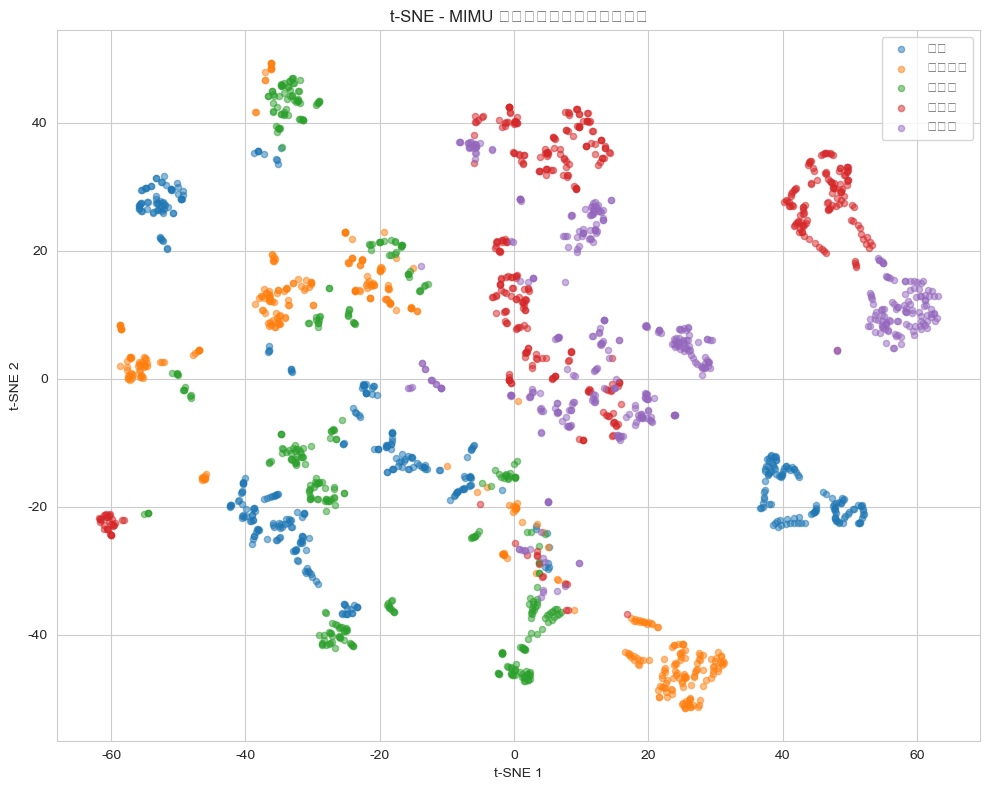

In [9]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for name in EXERCISES:
    mask = y == name
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=EXERCISES[name]["label"],
               alpha=0.5, s=20)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE - MIMU 特征空间中的运动类型分布")
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3608700465.py:19: UserWarning: Glyph 20165 (\N{CJK UNIFIED IDEOGRAPH-4EC5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3608700465.py:19: UserWarning: Glyph 31616 (\N{CJK UNIFIED IDEOGRAPH-7B80}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3608700465.py:19: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3608700465.py:19: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAPH-8FD0}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3608700465.py:19: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3608700465.py:19: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B})

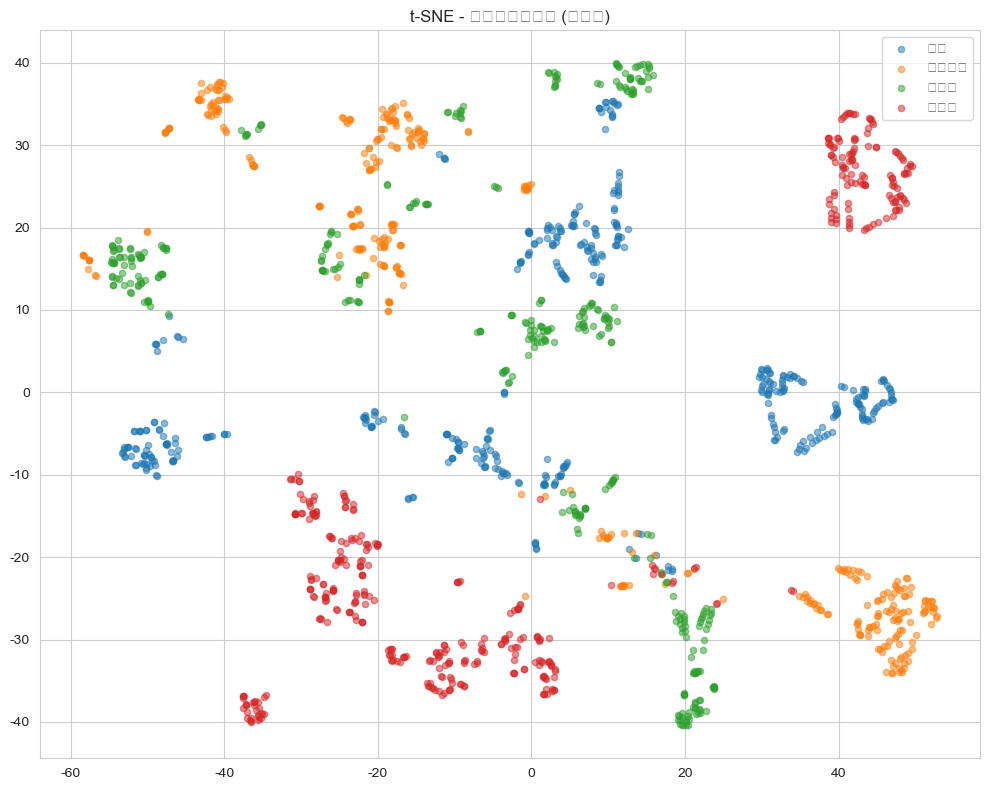

In [10]:
# 简单运动之间的可分性
simple_mask = df_all["complexity"] == "simple"
X_simple = X_scaled[simple_mask]
y_simple = y[simple_mask]

if len(np.unique(y_simple)) > 1:
    tsne_simple = TSNE(n_components=2, random_state=42, perplexity=30)
    X_tsne_simple = tsne_simple.fit_transform(X_simple)

    fig, ax = plt.subplots(figsize=(10, 8))
    for name in EXERCISES:
        if EXERCISES[name]["complexity"] != "simple":
            continue
        mask = y_simple == name
        ax.scatter(X_tsne_simple[mask, 0], X_tsne_simple[mask, 1],
                   label=EXERCISES[name]["label"], alpha=0.5, s=20)
    ax.set_title("t-SNE - 仅简单运动类型 (训练集)")
    ax.legend()
    plt.tight_layout()
    plt.show()

C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3982351325.py:17: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3982351325.py:17: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3982351325.py:17: UserWarning: Glyph 36339 (\N{CJK UNIFIED IDEOGRAPH-8DF3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3982351325.py:17: UserWarning: Glyph 20463 (\N{CJK UNIFIED IDEOGRAPH-4FEF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3982351325.py:17: UserWarning: Glyph 21351 (\N{CJK UNIFIED IDEOGRAPH-5367}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\26541\AppData\Local\Temp\ipykernel_13060\3982351325.py:17: UserWarning: Glyph 25745 (\N{CJK UNIFIED IDEOGRAPH-6491})

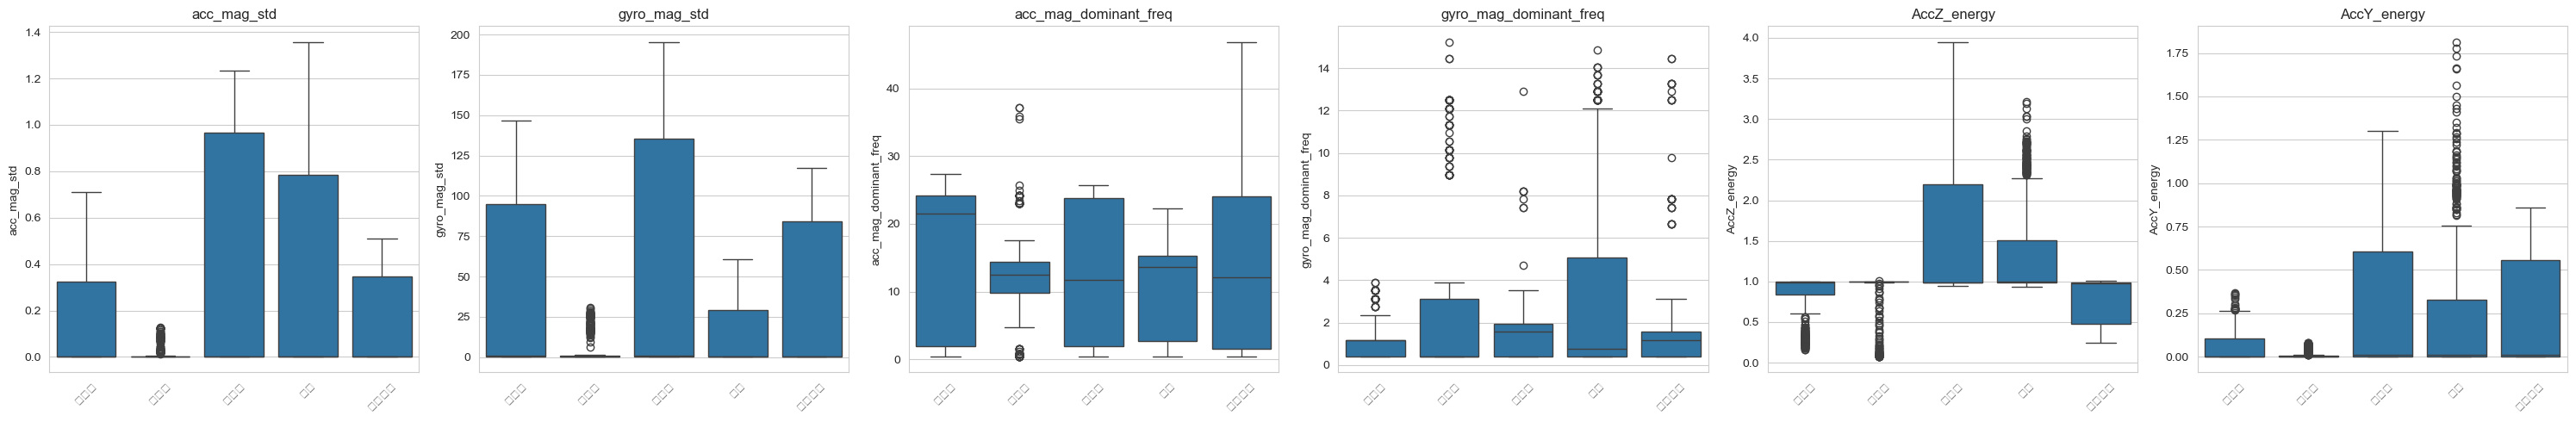

In [11]:
# 关键特征箱线图
df_feat = pd.DataFrame(X, columns=FEATURE_NAMES)
df_feat["exercise_label"] = labels

key_features = ["acc_mag_std", "gyro_mag_std", "acc_mag_dominant_freq",
                "gyro_mag_dominant_freq", "AccZ_energy", "AccY_energy"]
existing = [f for f in key_features if f in df_feat.columns]

fig, axes = plt.subplots(1, len(existing), figsize=(5 * len(existing), 5))
if len(existing) == 1:
    axes = [axes]
for ax, feat_name in zip(axes, existing):
    sns.boxplot(data=df_feat, x="exercise_label", y=feat_name, ax=ax)
    ax.set_title(feat_name)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. 保存

In [ ]:
output_path = ARTIFACTS_DIR / "mimu_features_all.pkl"
save_data = {
    "df": df_all[["window_time", "exercise", "exercise_label", "complexity",
                   "file_name", "features", "is_motion"]],
    "X": X,
    "y": y,
    "labels": labels,
    "feature_names": FEATURE_NAMES,
    "motion_threshold": MOTION_THRESHOLD,
}
with open(output_path, "wb") as f:
    pickle.dump(save_data, f)
print(f"已保存到: {output_path}")
print(f"  特征维度: {X.shape[1]}")
print(f"  总窗口数: {X.shape[0]} (运动 {df_all['is_motion'].sum()}, 静息 {(~df_all['is_motion']).sum()})")